In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("./user_behavior_dataset.csv")
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [4]:
df.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

In [5]:
df.drop("User ID",axis=1,inplace=True)

In [6]:
df_data_processing=df.copy()

In [7]:
df_data_processing=pd.get_dummies(df_data_processing)

In [8]:
df_data_processing.head()

,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class,Device Model_Google Pixel 5,Device Model_OnePlus 9,Device Model_Samsung Galaxy S21,Device Model_Xiaomi Mi 11,Device Model_iPhone 12,Operating System_Android,Operating System_iOS,Gender_Female,Gender_Male
0,393,6.4,1872,67,1122,40,4,True,False,False,False,False,True,False,False,True
1,268,4.7,1331,42,944,47,3,False,True,False,False,False,True,False,True,False
2,154,4.0,761,32,322,42,2,False,False,False,True,False,True,False,False,True
3,239,4.8,1676,56,871,20,3,True,False,False,False,False,True,False,False,True
4,187,4.3,1367,58,988,31,3,False,False,False,False,True,False,True,True,False


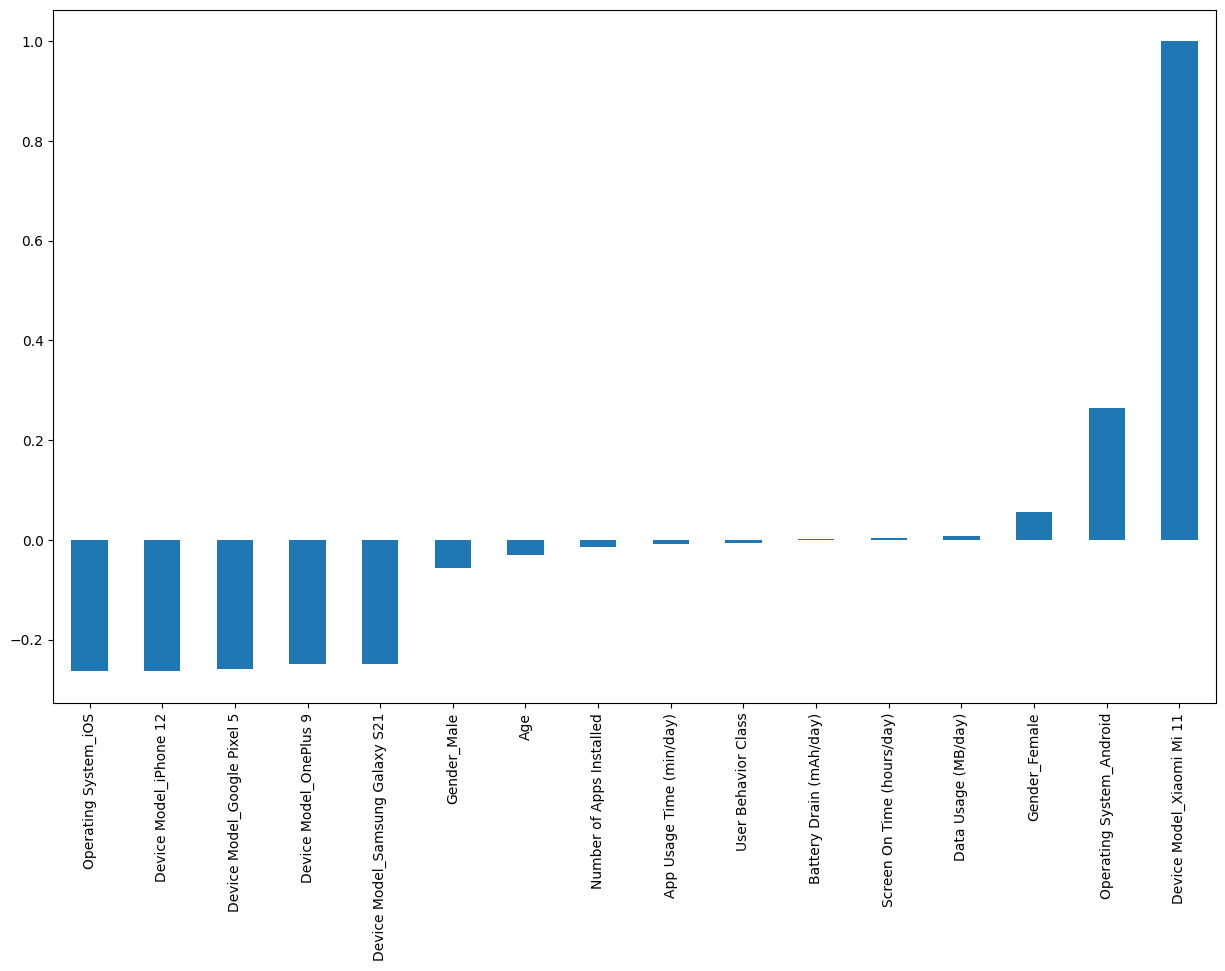

In [9]:
fig = plt.figure(figsize=(15,9))
df_data_processing.corr()['Device Model_Xiaomi Mi 11'].sort_values(ascending=True).plot(kind='bar')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [11]:
scaler = MinMaxScaler()
df_data_processing_scaled = scaler.fit_transform(df_data_processing)

In [12]:
df_data_processing_scaled=pd.DataFrame(df_data_processing_scaled)

In [13]:
df_data_processing_scaled.columns=df_data_processing.columns

In [14]:
df_data_processing_scaled.head()

,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class,Device Model_Google Pixel 5,Device Model_OnePlus 9,Device Model_Samsung Galaxy S21,Device Model_Xiaomi Mi 11,Device Model_iPhone 12,Operating System_Android,Operating System_iOS,Gender_Female,Gender_Male
0,0.639085,0.490909,0.583426,0.640449,0.425887,0.536585,0.75,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.419014,0.336364,0.382386,0.359551,0.351566,0.707317,0.50,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.218310,0.272727,0.170569,0.247191,0.091858,0.585366,0.25,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.367958,0.345455,0.510591,0.516854,0.321086,0.048780,0.50,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.276408,0.300000,0.395764,0.539326,0.369937,0.317073,0.50,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=101)

NameError: name 'X' is not defined

In [16]:
from sklearn.preprocessing import StandardScaler
scaler_x=StandardScaler()
scaler_x.fit(X_train)

NameError: name 'X_train' is not defined

In [17]:
X_train=pd.DataFrame(scaler_x.transform(X_train),columns=X_train.columns)
Y_test=pd.DataFrame(scaler_x.transform(X_test),columns=X_test.columns)

NameError: name 'X_train' is not defined

In [20]:
sns.countplot(data=df,x='Device Model_Samsung Galaxy S21', hue='Gender')

ValueError: Could not interpret value `Device Model_Samsung Galaxy S21` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x1000 with 0 Axes>

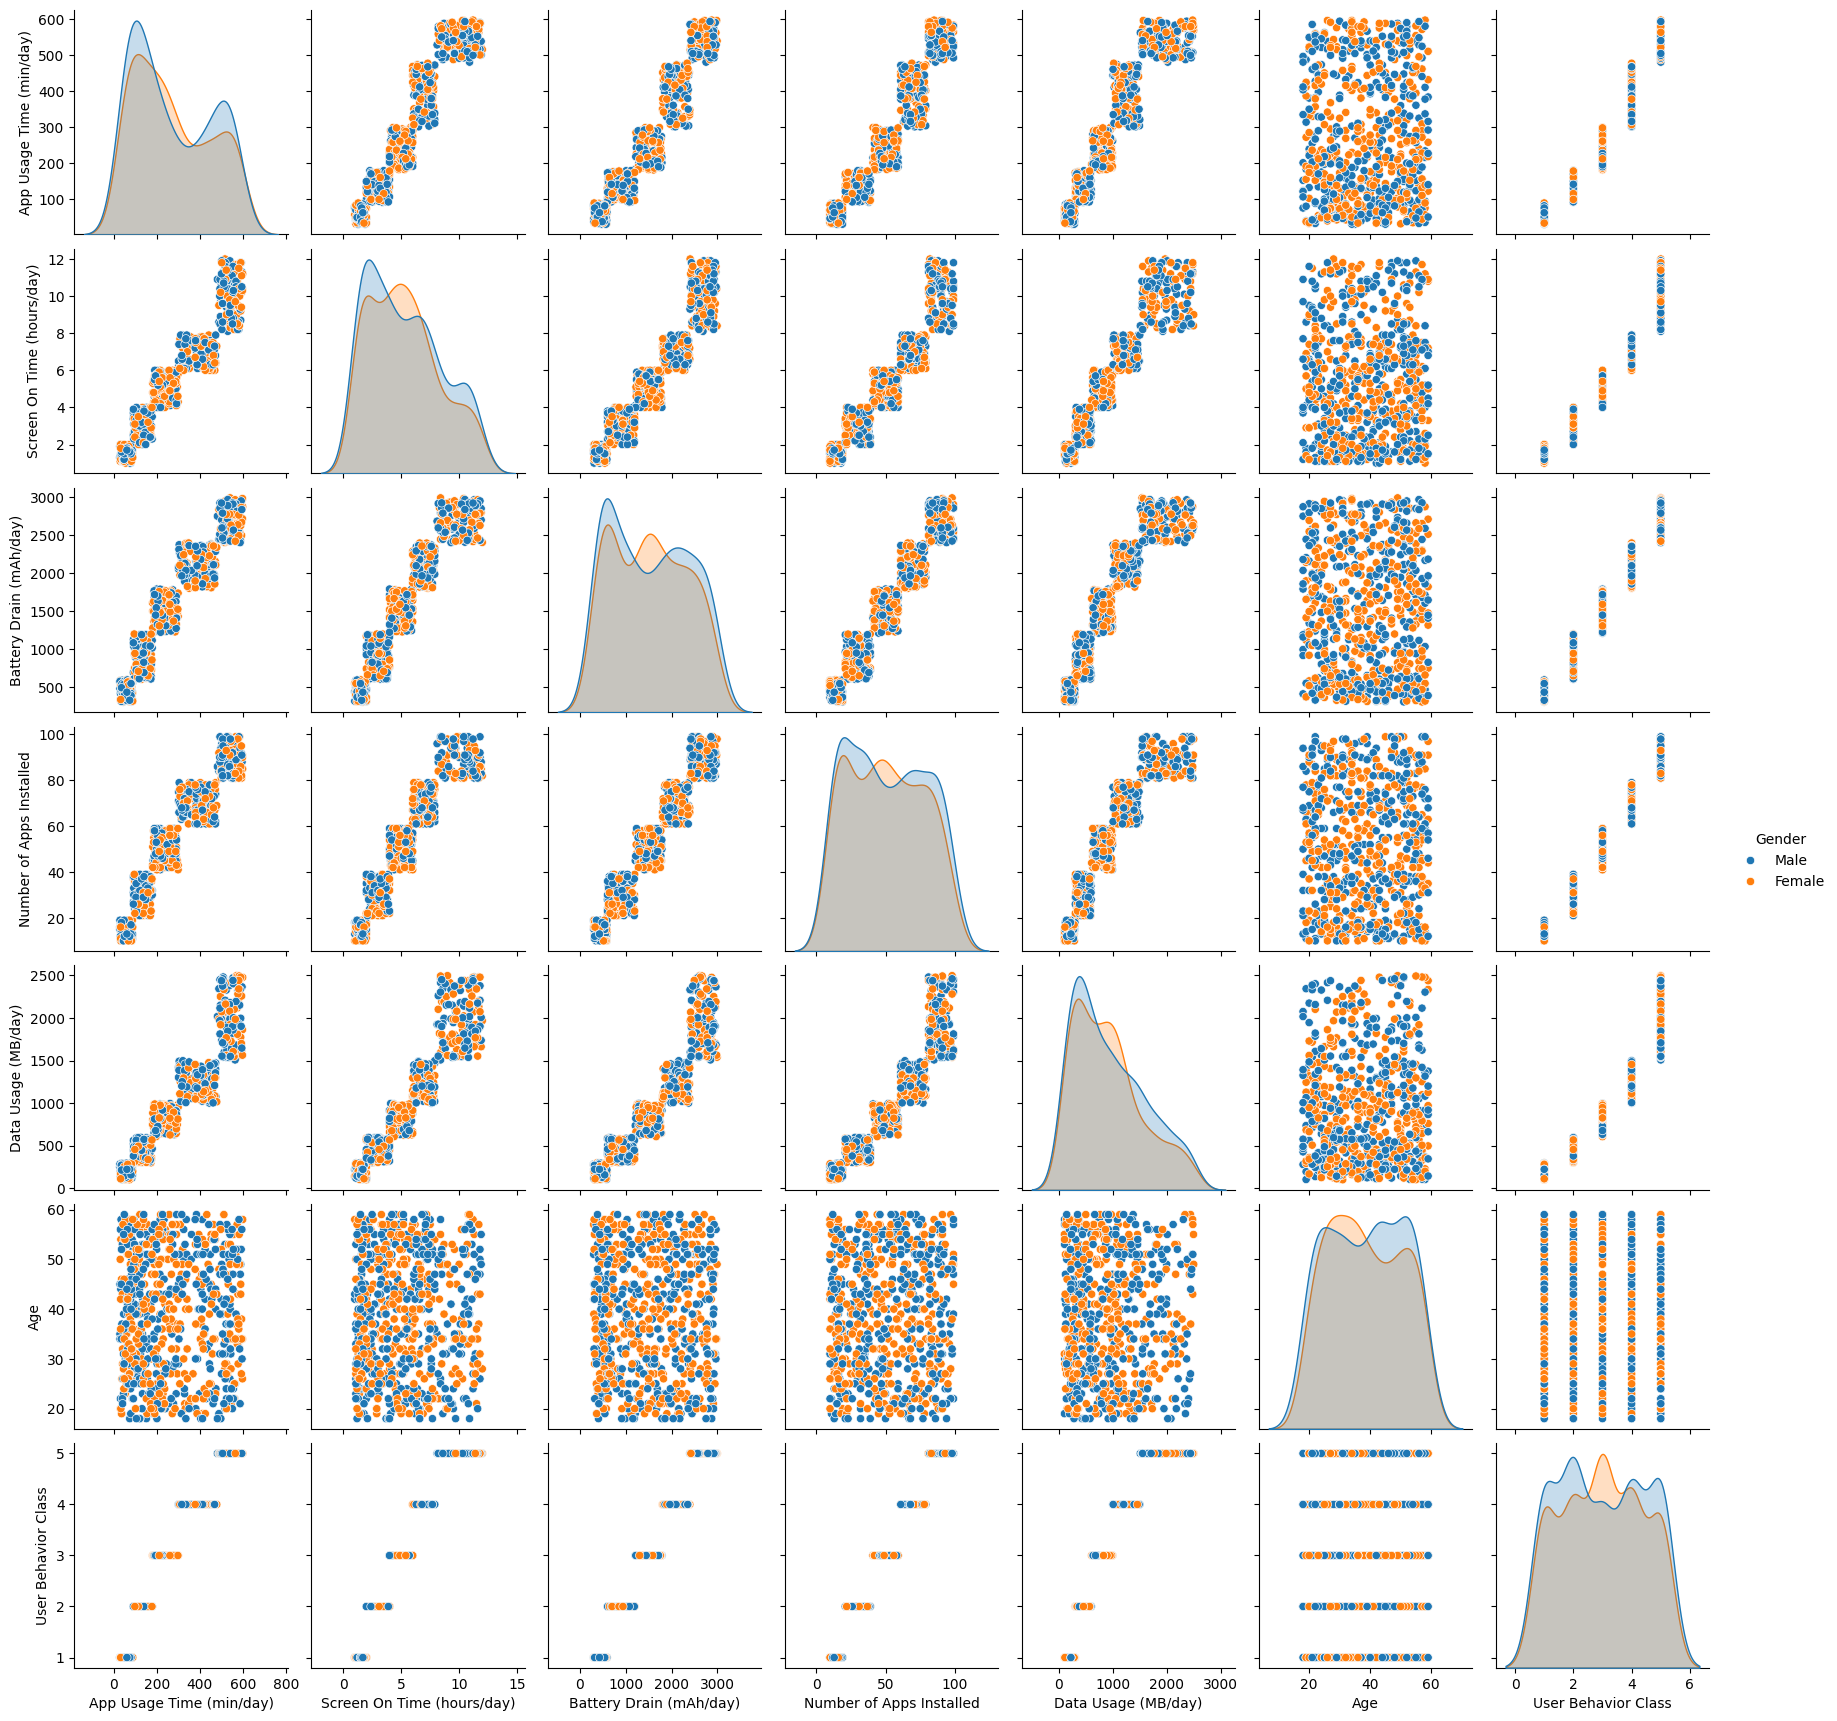

In [23]:
fig=plt.figure(figsize=(10,10))
sns.pairplot(data=df, hue='Gender')
plt.show()

In [53]:
X=df_data_processing_scaled.drop('Operating System_iOS',axis=1)
y=df_data_processing_scaled['Operating System_iOS'].values

In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.3, random_state=101)

In [55]:
X_train.shape

(490, 15)

In [56]:
X_test.shape

(210, 15)

In [57]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
result = model.fit(X_train, y_train)

In [52]:
from sklearn import metrics
prediction_test=model.predict(X_test)
print(metrics.accuracy_score(y_test, prediction_test))

1.0


In [58]:
model.predict_proba(X_test)

array([[0.99079681, 0.00920319],
       [0.99065449, 0.00934551],
       [0.99087153, 0.00912847],
       [0.03475626, 0.96524374],
       [0.99064665, 0.00935335],
       [0.98986577, 0.01013423],
       [0.99025073, 0.00974927],
       [0.9904689 , 0.0095311 ],
       [0.991189  , 0.008811  ],
       [0.99044718, 0.00955282],
       [0.9905487 , 0.0094513 ],
       [0.99071261, 0.00928739],
       [0.98950602, 0.01049398],
       [0.99149099, 0.00850901],
       [0.03401511, 0.96598489],
       [0.99035088, 0.00964912],
       [0.99015163, 0.00984837],
       [0.99147458, 0.00852542],
       [0.99070741, 0.00929259],
       [0.99002668, 0.00997332],
       [0.99049656, 0.00950344],
       [0.98993205, 0.01006795],
       [0.9907329 , 0.0092671 ],
       [0.99003573, 0.00996427],
       [0.9916183 , 0.0083817 ],
       [0.03341828, 0.96658172],
       [0.99009438, 0.00990562],
       [0.03197255, 0.96802745],
       [0.99006197, 0.00993803],
       [0.99112255, 0.00887745],
       [0.

In [59]:
model.coef_

array([[ 3.30841360e-02,  5.89747358e-03,  4.57392006e-02,
         4.24770078e-02,  3.25777599e-03,  2.89662392e-02,
         5.67910470e-02, -9.48532832e-01, -9.08306786e-01,
        -8.51131545e-01, -9.08334092e-01,  3.54054215e+00,
        -3.61630525e+00, -2.61760016e-02, -4.95871078e-02]])

In [60]:
model.feature_names_in_

array(['App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'User Behavior Class',
       'Device Model_Google Pixel 5', 'Device Model_OnePlus 9',
       'Device Model_Samsung Galaxy S21', 'Device Model_Xiaomi Mi 11',
       'Device Model_iPhone 12', 'Operating System_Android',
       'Gender_Female', 'Gender_Male'], dtype=object)

Axes(0.125,0.11;0.775x0.77)


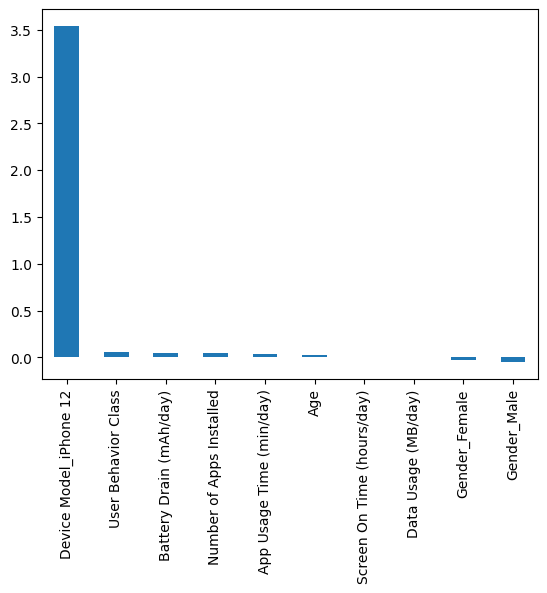

In [63]:
weights=pd.Series(model.coef_[0],
                index=X.columns.values)
print(weights.sort_values(ascending=False)[:10].plot(kind='bar'))